In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import tensorflow as tf
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose, Dropout
from keras.callbacks import ModelCheckpoint, EarlyStopping

# Dimensions expected by the U-Net
IMG_HEIGHT = 256
IMG_WIDTH = 256
IMG_CHANNELS = 3

# UPDATE these paths to where you extracted the 1 GB Deep-SAR dataset
IMG_PATH = r"C:\Users\MAYANK\Desktop\sih-2026\SpillTrace-SIH26\ml\oil-spill-new\images\images\train"
LABELS_PATH = r"C:\Users\MAYANK\Desktop\sih-2026\SpillTrace-SIH26\ml\oil-spill-new\masks\masks\train"

print("Setup completed successfully.")

Setup completed successfully.


In [5]:
image_files = sorted(os.listdir(IMG_PATH))
mask_files = sorted(os.listdir(LABELS_PATH))

X_data = []
Y_data = []

print("Loading and preprocessing images and masks...")
for img_name, mask_name in tqdm(zip(image_files, mask_files), total=len(image_files)):
    img_path = os.path.join(IMG_PATH, img_name)
    mask_path = os.path.join(LABELS_PATH, mask_name)

    # 1. Read and normalize image to [0, 1]
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    img = cv2.resize(img, (IMG_HEIGHT, IMG_WIDTH))
    img = img / 255.0
    X_data.append(img)

    # 2. Read mask in grayscale and binarize (Oil = 1.0, Water = 0.0)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_HEIGHT, IMG_WIDTH), interpolation=cv2.INTER_NEAREST)
    mask = (mask > 0).astype(np.float32)
    mask = np.expand_dims(mask, axis=-1)
    Y_data.append(mask)

X_data = np.array(X_data, dtype=np.float32)
Y_data = np.array(Y_data, dtype=np.float32)

print(f"\nImages array shape: {X_data.shape}")
print(f"Masks array shape: {Y_data.shape}")
print(f"Unique values in masks (must be [0. 1.]): {np.unique(Y_data)}")

# Split dataset (90% train, 10% validation)
X_train, X_val, y_train, y_val = train_test_split(X_data, Y_data, test_size=0.1, random_state=42)
print(f"Training set: {X_train.shape[0]} samples | Validation set: {X_val.shape[0]} samples")

Loading and preprocessing images and masks...


100%|██████████| 6455/6455 [02:51<00:00, 37.56it/s]



Images array shape: (6455, 256, 256, 3)
Masks array shape: (6455, 256, 256, 1)
Unique values in masks (must be [0. 1.]): [0. 1.]
Training set: 5809 samples | Validation set: 646 samples


In [6]:
def build_unet(input_shape):
    inputs = Input(input_shape)

    # Contracting Path (Encoder)
    c1 = Conv2D(16, (3, 3), activation="relu", kernel_initializer="he_normal", padding="same")(inputs)
    c1 = Dropout(0.1)(c1)
    c1 = Conv2D(16, (3, 3), activation="relu", kernel_initializer="he_normal", padding="same")(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(32, (3, 3), activation="relu", kernel_initializer="he_normal", padding="same")(p1)
    c2 = Dropout(0.1)(c2)
    c2 = Conv2D(32, (3, 3), activation="relu", kernel_initializer="he_normal", padding="same")(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(64, (3, 3), activation="relu", kernel_initializer="he_normal", padding="same")(p2)
    c3 = Dropout(0.2)(c3)
    c3 = Conv2D(64, (3, 3), activation="relu", kernel_initializer="he_normal", padding="same")(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = Conv2D(128, (3, 3), activation="relu", kernel_initializer="he_normal", padding="same")(p3)
    c4 = Dropout(0.2)(c4)
    c4 = Conv2D(128, (3, 3), activation="relu", kernel_initializer="he_normal", padding="same")(c4)
    p4 = MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = Conv2D(256, (3, 3), activation="relu", kernel_initializer="he_normal", padding="same")(p4)
    c5 = Dropout(0.3)(c5)
    c5 = Conv2D(256, (3, 3), activation="relu", kernel_initializer="he_normal", padding="same")(c5)

    # Expansive Path (Decoder)
    u6 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding="same")(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(128, (3, 3), activation="relu", kernel_initializer="he_normal", padding="same")(u6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv2D(128, (3, 3), activation="relu", kernel_initializer="he_normal", padding="same")(c6)

    u7 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(64, (3, 3), activation="relu", kernel_initializer="he_normal", padding="same")(u7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv2D(64, (3, 3), activation="relu", kernel_initializer="he_normal", padding="same")(c7)

    u8 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(32, (3, 3), activation="relu", kernel_initializer="he_normal", padding="same")(u8)
    c8 = Dropout(0.1)(c8)
    c8 = Conv2D(32, (3, 3), activation="relu", kernel_initializer="he_normal", padding="same")(c8)

    u9 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding="same")(c8)
    u9 = concatenate([u9, c1], axis=3)
    c9 = Conv2D(16, (3, 3), activation="relu", kernel_initializer="he_normal", padding="same")(u9)
    c9 = Dropout(0.1)(c9)
    c9 = Conv2D(16, (3, 3), activation="relu", kernel_initializer="he_normal", padding="same")(c9)

    # Output: 1 channel with Sigmoid activation for binary prediction
    outputs = Conv2D(1, (1, 1), activation="sigmoid")(c9)

    return Model(inputs, outputs)

tf.keras.backend.clear_session()
model = build_unet((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 256,  │          0 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      2,320 │ dropout[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 128,  │          0 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      9,248 │ dropout_1[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 64,    │          0 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     36,928 │ dropout_2[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32, 32,    │          0 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    147,584 │ dropout_3[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]  

 Total params: 1,941,105 (7.40 MB)

 Trainable params: 1,941,105 (7.40 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Compile with Binary Cross-Entropy
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Callbacks to save the best model weights (Changed .h5 to .keras)
callbacks = [
    ModelCheckpoint("unet_binary_spilltrace.keras", monitor="val_loss", verbose=1, save_best_only=True),
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
]

print("Starting training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=16,
    epochs=40,
    callbacks=callbacks,
    verbose=1
)

Starting training...
Epoch 1/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 999ms/step - accuracy: 0.7923 - loss: 0.4194
Epoch 1: val_loss improved from inf to 0.26726, saving model to unet_binary_spilltrace.keras
364/364 ━━━━━━━━━━━━━━━━━━━━ 389s 1s/step - accuracy: 0.7924 - loss: 0.4191 - val_accuracy: 0.8949 - val_loss: 0.2673
Epoch 2/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8998 - loss: 0.2534
Epoch 2: val_loss improved from 0.26726 to 0.25602, saving model to unet_binary_spilltrace.keras
364/364 ━━━━━━━━━━━━━━━━━━━━ 391s 1s/step - accuracy: 0.8999 - loss: 0.2534 - val_accuracy: 0.9013 - val_loss: 0.2560
Epoch 3/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9094 - loss: 0.2236
Epoch 3: val_loss did not improve from 0.25602
364/364 ━━━━━━━━━━━━━━━━━━━━ 395s 1s/step - accuracy: 0.9094 - loss: 0.2236 - val_accuracy: 0.8616 - val_loss: 0.2905
Epoch 4/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9060 - loss: 0.2285
Epoch 4: val_loss improved from 0.25602 to 0.

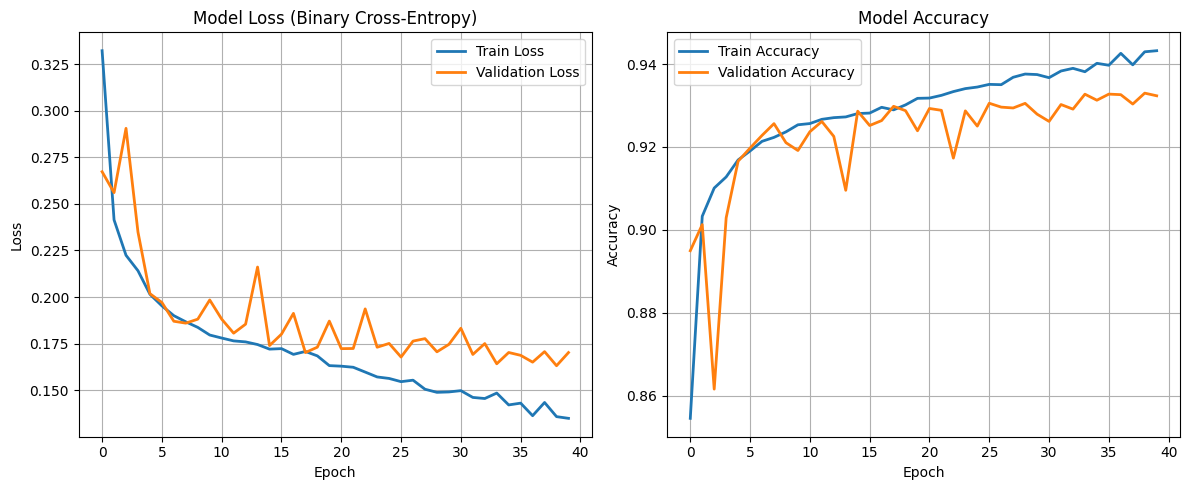

Generating predictions for 4 validation samples...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step


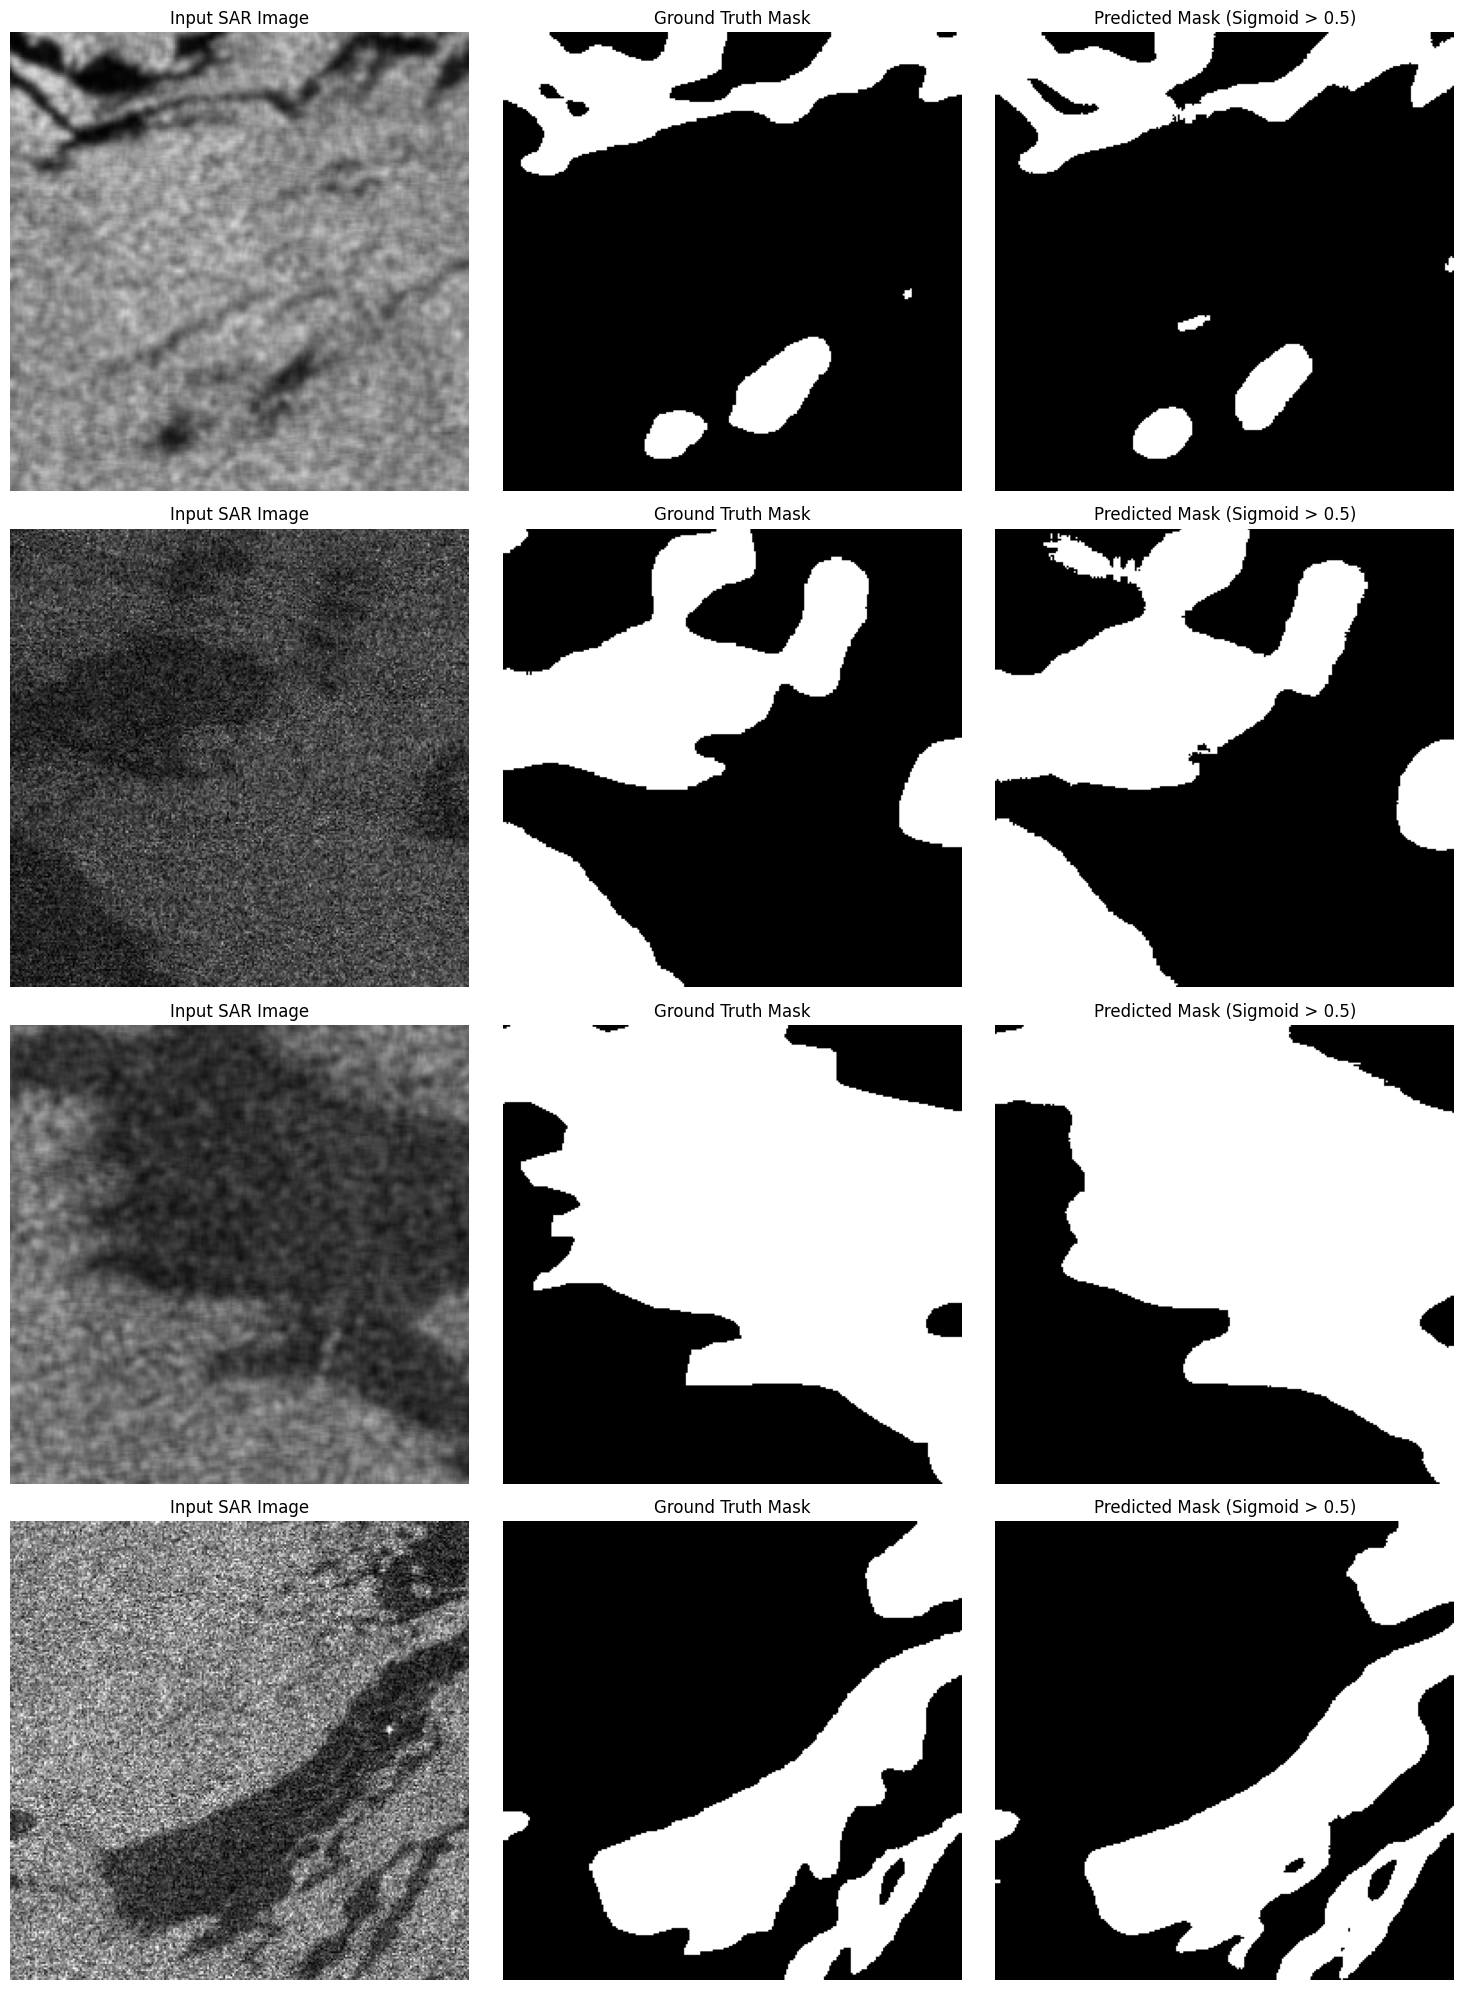

In [9]:
# %%
# 1. Plot Training & Validation Curves
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss", linewidth=2)
plt.plot(history.history["val_loss"], label="Validation Loss", linewidth=2)
plt.title("Model Loss (Binary Cross-Entropy)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy", linewidth=2)
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", linewidth=2)
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# %%
# 2. Visualize Predictions vs Ground Truth Masks
def visualize_predictions(model, X_subset, y_subset, num_samples=3):
    print(f"Generating predictions for {num_samples} validation samples...")
    preds = model.predict(X_subset[:num_samples])
    preds_binary = (preds > 0.5).astype(np.float32)

    plt.figure(figsize=(15, 5 * num_samples))
    for i in range(num_samples):
        # Original Image
        plt.subplot(num_samples, 3, i * 3 + 1)
        plt.imshow(X_subset[i])
        plt.title("Input SAR Image")
        plt.axis("off")

        # Ground Truth Mask
        plt.subplot(num_samples, 3, i * 3 + 2)
        plt.imshow(y_subset[i].squeeze(), cmap="gray")
        plt.title("Ground Truth Mask")
        plt.axis("off")

        # Predicted Mask
        plt.subplot(num_samples, 3, i * 3 + 3)
        plt.imshow(preds_binary[i].squeeze(), cmap="gray")
        plt.title("Predicted Mask (Sigmoid > 0.5)")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Run the visualization on validation data
visualize_predictions(model, X_val, y_val, num_samples=4)

In [10]:
# %%
# Save the final entire model (.keras format)
final_model_path = "unet_final_spilltrace.keras"
model.save(final_model_path)
print(f"Final model successfully saved to {final_model_path}")

Final model successfully saved to unet_final_spilltrace.keras
